# Evaluación Parcial 1 Caso C Spotify Tracks

## Informe técnico reproducible

Este proyecto analiza las características disponibles de canciones para comprender su asociación con `popularity` y dejar una base correcta para un futuro modelo de regresión. El alcance actual es comprensión, calidad, preparación y análisis exploratorio de datos; no se entrenan ni reportan métricas de un modelo todavía.

## 👥 Integrantes del equipo

### Integrantes

- **Sebastián Aird**
- **Bastián Roman**
- **Vicente Contreras**
- **Ignacio Gómez**

---

## 👨‍🏫 Información académica

**Asignatura:** MLY1101 - Machine Learning  
**Evaluación:** Evaluación Parcial N°1 - Caso C: Spotify Tracks  
**Institución:** Duoc UC  
**Docente:** CLAUDIO ANDRES ZAMORANO SANCHEZ

**Año:** 2026

---

## 📚 Proyecto

**Caso C: Inteligencia musical y predicción de popularidad de canciones (Spotify Tracks)**

El proyecto corresponde a la Evaluación Parcial N°1 de la asignatura **MLY1101 - Machine Learning**, enfocada en la comprensión del problema, análisis exploratorio de datos (EDA), evaluación de calidad, preparación de datos y análisis de aspectos éticos relacionados con el uso de los datos.

## Índice completo del informe

1. Descripción del problema de negocio  
2. Objetivos del proyecto  
3. KPIs  
4. Fuente de datos  
5. Herramientas utilizadas  
6. Importación de librerías  
7. Carga de datos  
8. Inspección inicial  
9. Calidad de datos  
10. Valores faltantes  
11. Duplicados  
12. Tipos y cardinalidad  
13. Estadística descriptiva  
14. Variable objetivo popularity  
15. Análisis de variables musicales  
16. Relaciones y correlaciones  
17. Análisis categórico por género  
18. Análisis de contenido explícito  
19. Validación de rangos  
20. Detección de outliers  
21. Preparación de datos  
22. Dataset preparado y comparación antes después  
23. Selección preliminar de variables  
24. Prevención de data leakage  
25. CRISP DM  
26. Sesgos ética privacidad y limitaciones  
27. Conclusiones  
28. Checklist de cumplimiento

## 1. Descripción del problema de negocio

**Pregunta de negocio.** ¿Podemos estimar la popularidad de una canción a partir de sus características musicales y metadatos disponibles? El resultado puede apoyar análisis de catálogo y contenidos, sin representar una funcionalidad real de Spotify.

## 2. Objetivos del proyecto

**Objetivo general.** Analizar y preparar los datos para una futura solución de regresión capaz de estimar la popularidad de canciones utilizando las características disponibles en el dataset Spotify Tracks.

**Objetivos específicos.**

1. Identificar y describir las fuentes y variables disponibles.
2. Evaluar la calidad de los datos.
3. Identificar valores faltantes.
4. Identificar duplicados.
5. Examinar tipos y cardinalidad.
6. Analizar estadísticamente las variables.
7. Explorar la distribución de `popularity`.
8. Identificar relaciones entre `popularity` y variables musicales.
9. Analizar diferencias por género y contenido explícito.
10. Detectar valores inválidos y valores atípicos.
11. Preparar los datos para una futura etapa de modelamiento.
12. Prevenir data leakage.
13. Evaluar sesgos, ética y privacidad.
14. Documentar el proceso mediante CRISP DM.

## 3. KPIs

| KPI | Uso | Estado en esta etapa |
|---|---|---|
| MAE | Error promedio absoluto de una predicción | Se calculará en modelamiento |
| RMSE | Penaliza errores de predicción grandes | Se calculará en modelamiento |
| R² | Variabilidad explicada por el modelo | Se calculará en modelamiento |
| Porcentaje de faltantes | Calidad de datos | Se calcula en este notebook |
| Porcentaje de duplicados | Calidad de datos | Se calcula en este notebook |

## 4. Fuente de datos

La fuente principal es `data/dataset.csv`, correspondiente al Caso C: Spotify Tracks. Contiene metadatos de pistas, información de álbumes y artistas, la variable objetivo `popularity` y características musicales como energía, bailabilidad, sonoridad, tempo y valencia. Las dimensiones reales se calculan tras la carga, no se fijan manualmente. El material disponible no permite determinar con certeza el método original de captura del dataset.

## 5. Herramientas utilizadas

Python es el lenguaje de análisis. Pandas se emplea para la manipulación tabular, NumPy para cálculos numéricos, Matplotlib para visualizaciones y SciPy para análisis estadístico de asociación categórica. Jupyter Notebook o Google Colab son entornos de ejecución y documentación, no fuentes de datos.

## 6. Importación de librerías

In [47]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from IPython.display import display, Markdown

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
plt.style.use("seaborn-v0_8-whitegrid")

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 7. Carga de datos

In [48]:
possible_paths = [Path("data/dataset.csv"), Path("../data/dataset.csv"), Path("dataset.csv")]
data_path = next((path for path in possible_paths if path.exists()), None)

if data_path is None:
    try:
        from google.colab import files
        uploaded = files.upload()
        data_path = Path(next(iter(uploaded)))
    except ImportError as exc:
        raise FileNotFoundError(
            "No se encontró dataset.csv. Ejecute el notebook desde notebooks/ "
            "dentro de la estructura del proyecto o cargue el archivo en Google Colab."
        ) from exc

df = pd.read_csv(data_path)
print(f"Archivo utilizado: {data_path.resolve()}")
print(f"Dimensiones reales: {df.shape[0]:,} filas y {df.shape[1]:,} columnas.")
display(df.head())

Archivo utilizado: C:\Users\Roma\Documents\proyectos dudoc\spoty\Spotify_EP1_Proyecto\data\dataset.csv
Dimensiones reales: 114,000 filas y 21 columnas.


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,1,-6.746,0,0.143,0.032,0.000,0.358,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.166,1,-17.235,1,0.076,0.924,0.000,0.101,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.359,0,-9.734,1,0.056,0.210,0.000,0.117,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.060,0,-18.515,1,0.036,0.905,0.000,0.132,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.443,2,-9.681,1,0.053,0.469,0.000,0.083,0.167,119.949,4,acoustic


## 8. Inspección inicial

In [49]:
print("Tipos de datos y memoria:")
df.info()

quality_summary = pd.DataFrame({
    "columna": df.columns,
    "tipo": df.dtypes.astype(str).values,
    "faltantes": df.isna().sum().values,
    "porcentaje_faltante": (df.isna().mean() * 100).round(3).values,
    "valores_unicos": df.nunique(dropna=True).values,
}).set_index("columna")
quality_summary["posibles_problemas"] = "Sin alerta inicial"
display(quality_summary)

Tipos de datos y memoria:
<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  str    
 2   artists           113999 non-null  str    
 3   album_name        113999 non-null  str    
 4   track_name        113999 non-null  str    
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liven

,tipo,faltantes,porcentaje_faltante,valores_unicos,posibles_problemas
columna,,,,,
Unnamed: 0,int64,0,0.000,114000,Sin alerta inicial
track_id,str,0,0.000,89741,Sin alerta inicial
artists,str,1,0.001,31437,Sin alerta inicial
album_name,str,1,0.001,46589,Sin alerta inicial
track_name,str,1,0.001,73608,Sin alerta inicial
popularity,int64,0,0.000,101,Sin alerta inicial
duration_ms,int64,0,0.000,50697,Sin alerta inicial
explicit,bool,0,0.000,2,Sin alerta inicial
danceability,float64,0,0.000,1174,Sin alerta inicial


## 9. Calidad de datos

In [50]:
quality_metrics = pd.DataFrame({
    "indicador": ["Filas", "Columnas", "Faltantes totales", "Porcentaje de faltantes", "Duplicados exactos", "Porcentaje de duplicados exactos"],
    "valor": [
        len(df), df.shape[1], int(df.isna().sum().sum()),
        (df.isna().sum().sum() / df.size) * 100, int(df.duplicated().sum()),
        df.duplicated().mean() * 100,
    ],
})
display(quality_metrics)
print("La siguiente revisión desagrega cada dimensión de calidad; ningún registro se elimina automáticamente en esta etapa.")

,indicador,valor
0,Filas,"114,000.000"
1,Columnas,21.000
2,Faltantes totales,3.000
3,Porcentaje de faltantes,0.000
4,Duplicados exactos,0.000
5,Porcentaje de duplicados exactos,0.000


La siguiente revisión desagrega cada dimensión de calidad; ningún registro se elimina automáticamente en esta etapa.


## 10. Valores faltantes

In [51]:
missing = quality_summary.loc[quality_summary["faltantes"] > 0,
                              ["tipo", "faltantes", "porcentaje_faltante"]].sort_values("faltantes", ascending=False)
if missing.empty:
    print("No se encontraron valores faltantes.")
else:
    display(missing)
    print(f"Se identificaron {int(missing['faltantes'].sum()):,} valores faltantes en {len(missing)} columna(s).")

,tipo,faltantes,porcentaje_faltante
columna,,,
artists,str,1,0.001
album_name,str,1,0.001
track_name,str,1,0.001


Se identificaron 3 valores faltantes en 3 columna(s).


## 11. Duplicados exactos y por identificador

In [52]:
exact_duplicates = int(df.duplicated().sum())
exact_duplicates_pct = exact_duplicates / len(df) * 100

repeated_id_mask = df["track_id"].duplicated(keep=False) if "track_id" in df else pd.Series(False, index=df.index)
additional_track_id_repetitions = int(df["track_id"].duplicated().sum()) if "track_id" in df else 0
additional_track_id_repetitions_pct = additional_track_id_repetitions / len(df) * 100
records_with_repeated_ids = int(repeated_id_mask.sum())
records_with_repeated_ids_pct = records_with_repeated_ids / len(df) * 100
unique_track_ids = int(df["track_id"].nunique()) if "track_id" in df else 0

duplicate_summary = pd.DataFrame([
    ["Duplicados exactos", exact_duplicates, exact_duplicates_pct],
    ["Repeticiones adicionales de track_id", additional_track_id_repetitions, additional_track_id_repetitions_pct],
    ["Registros pertenecientes a IDs repetidos", records_with_repeated_ids, records_with_repeated_ids_pct],
], columns=["Métrica", "Cantidad", "Porcentaje"])
display(duplicate_summary)
print(f"track_id únicos: {unique_track_ids:,}.")
print("Los duplicados exactos repiten toda la fila. Las repeticiones adicionales de track_id excluyen la primera aparición de cada ID, mientras que el total de registros asociados a IDs repetidos incluye todas sus apariciones.")
print("Los registros con track_id repetido no se eliminan automáticamente: pueden corresponder a versiones, álbumes o registros distintos que requieren contexto adicional.")

,Métrica,Cantidad,Porcentaje
0,Duplicados exactos,0,0.000
1,Repeticiones adicionales de track_id,24259,21.280
2,Registros pertenecientes a IDs repetidos,40900,35.877


track_id únicos: 89,741.
Los duplicados exactos repiten toda la fila. Las repeticiones adicionales de track_id excluyen la primera aparición de cada ID, mientras que el total de registros asociados a IDs repetidos incluye todas sus apariciones.
Los registros con track_id repetido no se eliminan automáticamente: pueden corresponder a versiones, álbumes o registros distintos que requieren contexto adicional.


## 12. Tipos de datos y cardinalidad

In [53]:
cardinality_before = pd.DataFrame({
    "tipo_antes": df.dtypes.astype(str),
    "valores_unicos": df.nunique(dropna=True),
    "faltantes": df.isna().sum(),
})
display(cardinality_before)
print("Los textos e identificadores presentan alta cardinalidad; explicit y track_genre son de naturaleza categórica. La conversión se aplica más adelante sobre la copia de trabajo.")

,tipo_antes,valores_unicos,faltantes
Unnamed: 0,int64,114000,0
track_id,str,89741,0
artists,str,31437,1
album_name,str,46589,1
track_name,str,73608,1
popularity,int64,101,0
duration_ms,int64,50697,0
explicit,bool,2,0
danceability,float64,1174,0
energy,float64,2083,0


Los textos e identificadores presentan alta cardinalidad; explicit y track_genre son de naturaleza categórica. La conversión se aplica más adelante sobre la copia de trabajo.


## 13. Estadística descriptiva de variables numéricas

In [54]:
numeric_features = [c for c in ["duration_ms", "danceability", "energy", "key", "loudness", "mode", "speechiness", "acousticness", "instrumentalness", "liveness", "valence", "tempo", "time_signature"] if c in df]
display(df[numeric_features].describe().T)
print("La tabla presenta conteo, media, desviación estándar, mínimo, cuartiles y máximo para las variables numéricas disponibles.")

,count,mean,std,min,25%,50%,75%,max
duration_ms,"114,000.000","228,029.153","107,297.713",0.000,"174,066.000","212,906.000","261,506.000","5,237,295.000"
danceability,"114,000.000",0.567,0.174,0.000,0.456,0.580,0.695,0.985
energy,"114,000.000",0.641,0.252,0.000,0.472,0.685,0.854,1.000
key,"114,000.000",5.309,3.560,0.000,2.000,5.000,8.000,11.000
loudness,"114,000.000",-8.259,5.029,-49.531,-10.013,-7.004,-5.003,4.532
mode,"114,000.000",0.638,0.481,0.000,0.000,1.000,1.000,1.000
speechiness,"114,000.000",0.085,0.106,0.000,0.036,0.049,0.085,0.965
acousticness,"114,000.000",0.315,0.333,0.000,0.017,0.169,0.598,0.996
instrumentalness,"114,000.000",0.156,0.310,0.000,0.000,0.000,0.049,1.000
liveness,"114,000.000",0.214,0.190,0.000,0.098,0.132,0.273,1.000


La tabla presenta conteo, media, desviación estándar, mínimo, cuartiles y máximo para las variables numéricas disponibles.


## 14. Variable objetivo popularity

,popularity
count,"114,000.000"
mean,33.239
std,22.305
min,0.000
1%,0.000
5%,0.000
25%,17.000
50%,35.000
75%,50.000
95%,69.000


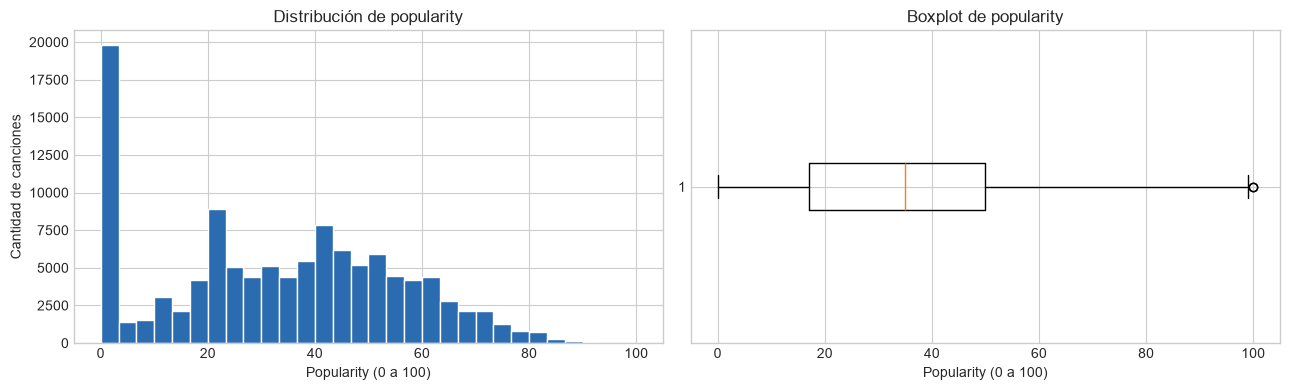

Popularity tiene media 33.24, mediana 35.00, desviación estándar 22.31 y asimetría 0.046. La interpretación se basa en la distribución observada y no implica causalidad.


In [55]:
pop_stats = df["popularity"].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99])
display(pop_stats.to_frame("popularity"))
skewness = df["popularity"].skew()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(df["popularity"], bins=30, color="#2b6cb0", edgecolor="white")
axes[0].set(title="Distribución de popularity", xlabel="Popularity (0 a 100)", ylabel="Cantidad de canciones")
axes[1].boxplot(df["popularity"].dropna(), orientation="horizontal")
axes[1].set(title="Boxplot de popularity", xlabel="Popularity (0 a 100)")
plt.tight_layout(); plt.show()
print(f"Popularity tiene media {pop_stats['mean']:.2f}, mediana {pop_stats['50%']:.2f}, desviación estándar {pop_stats['std']:.2f} y asimetría {skewness:.3f}. La interpretación se basa en la distribución observada y no implica causalidad.")

## 15. Análisis de variables musicales

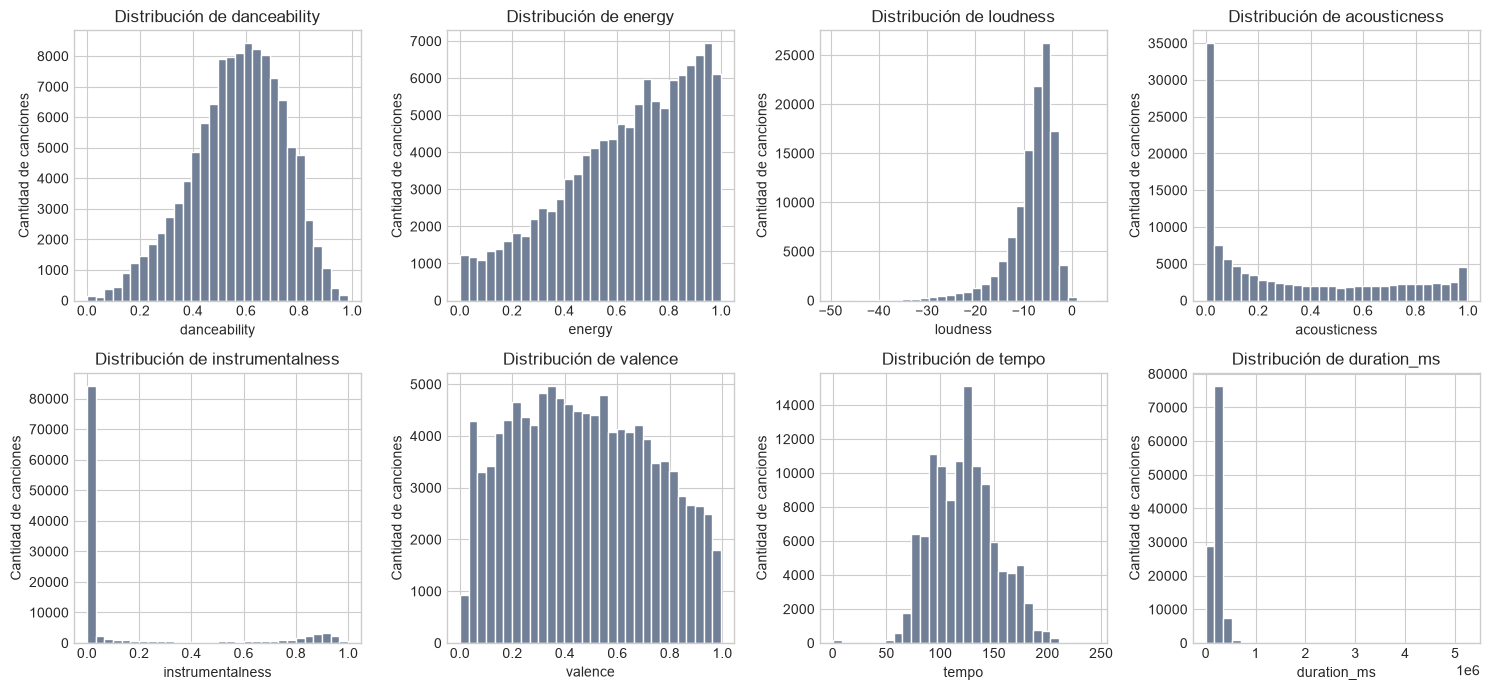

Las distribuciones complementan la estadística descriptiva y permiten examinar concentración, asimetría y valores poco frecuentes antes del modelamiento.


In [56]:
distribution_features = [column for column in ["danceability", "energy", "loudness", "acousticness", "instrumentalness", "valence", "tempo", "duration_ms"] if column in df]
fig, axes = plt.subplots(2, 4, figsize=(15, 7))
for ax, column in zip(axes.flat, distribution_features):
    ax.hist(df[column].dropna(), bins=30, color="#718096", edgecolor="white")
    ax.set_title(f"Distribución de {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Cantidad de canciones")
for ax in axes.flat[len(distribution_features):]:
    ax.set_visible(False)
plt.tight_layout(); plt.show()
print("Las distribuciones complementan la estadística descriptiva y permiten examinar concentración, asimetría y valores poco frecuentes antes del modelamiento.")

## 16. Relaciones y correlaciones con popularity

,pearson,spearman,abs_pearson
instrumentalness,-0.095,-0.078,0.095
loudness,0.050,0.035,0.050
speechiness,-0.045,-0.068,0.045
valence,-0.041,-0.042,0.041
danceability,0.035,0.027,0.035
time_signature,0.031,0.036,0.031
acousticness,-0.025,0.008,0.025
mode,-0.014,-0.015,0.014
tempo,0.013,0.017,0.013
duration_ms,-0.007,0.028,0.007


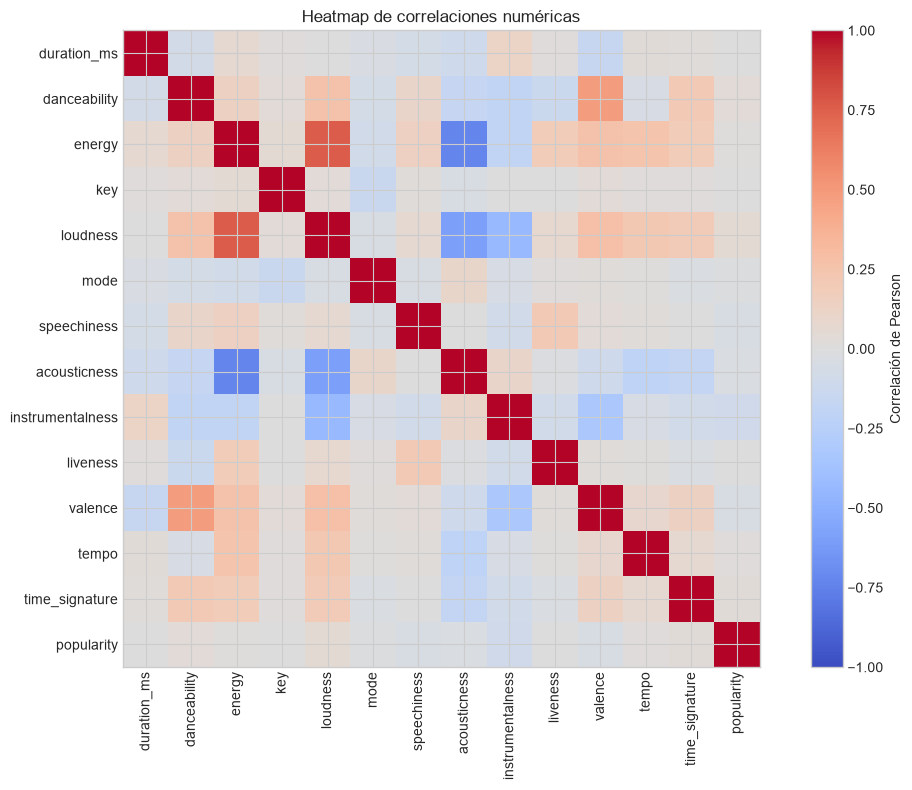

La mayor asociación lineal absoluta con popularity es instrumentalness (-0.095). Es una asociación exploratoria, no evidencia de causalidad.


In [57]:
pearson = df[numeric_features + ["popularity"]].corr(method="pearson")["popularity"].drop("popularity")
spearman = df[numeric_features + ["popularity"]].corr(method="spearman")["popularity"].drop("popularity")
associations = pd.DataFrame({"pearson": pearson, "spearman": spearman})
associations["abs_pearson"] = associations["pearson"].abs()
associations = associations.sort_values("abs_pearson", ascending=False)
display(associations)

matrix = df[numeric_features + ["popularity"]].corr(method="pearson")
fig, ax = plt.subplots(figsize=(11, 8))
image = ax.imshow(matrix, vmin=-1, vmax=1, cmap="coolwarm")
ax.set_xticks(range(len(matrix.columns)), matrix.columns, rotation=90)
ax.set_yticks(range(len(matrix.index)), matrix.index)
fig.colorbar(image, ax=ax, label="Correlación de Pearson")
ax.set_title("Heatmap de correlaciones numéricas")
plt.tight_layout(); plt.show()

top_association = associations.index[0]
top_value = associations.iloc[0]["pearson"]
print(f"La mayor asociación lineal absoluta con popularity es {top_association} ({top_value:.3f}). Es una asociación exploratoria, no evidencia de causalidad.")

### 14.1 Visualización de relaciones variable objetivo

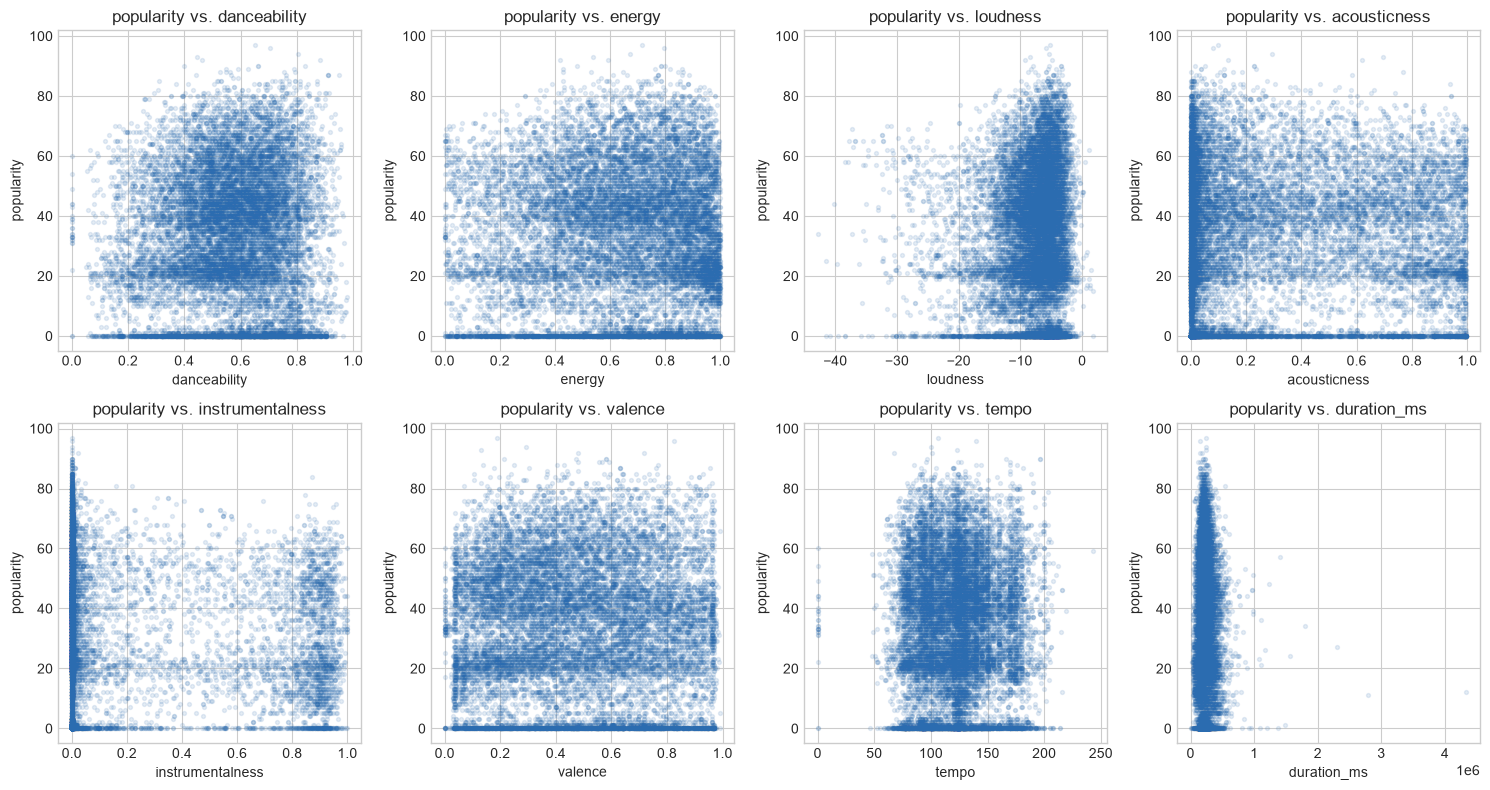

Se usa una muestra reproducible para mantener los gráficos legibles; las correlaciones de la sección anterior se calculan sobre todos los registros.


In [58]:
plot_features = [c for c in ["danceability", "energy", "loudness", "acousticness", "instrumentalness", "valence", "tempo", "duration_ms"] if c in df]
sample = df.sample(min(15000, len(df)), random_state=42)
fig, axes = plt.subplots(2, 4, figsize=(15, 8))
for ax, column in zip(axes.flat, plot_features):
    ax.scatter(sample[column], sample["popularity"], alpha=.12, s=8, color="#2b6cb0")
    ax.set_xlabel(column); ax.set_ylabel("popularity"); ax.set_title(f"popularity vs. {column}")
for ax in axes.flat[len(plot_features):]: ax.set_visible(False)
plt.tight_layout(); plt.show()
print("Se usa una muestra reproducible para mantener los gráficos legibles; las correlaciones de la sección anterior se calculan sobre todos los registros.")

## 17. Análisis categórico por género musical

,count,mean,median,std
track_genre,,,,
chicago-house,1000,12.339,10.000,9.582
breakbeat,1000,20.123,14.000,12.856
black-metal,1000,22.449,19.000,9.411
alternative,1000,24.337,1.000,32.660
afrobeat,1000,24.399,21.000,10.513
bluegrass,1000,25.676,24.000,7.944
blues,1000,31.188,34.000,27.484
alt-rock,1000,33.943,45.000,31.154
cantopop,1000,34.739,35.000,13.593


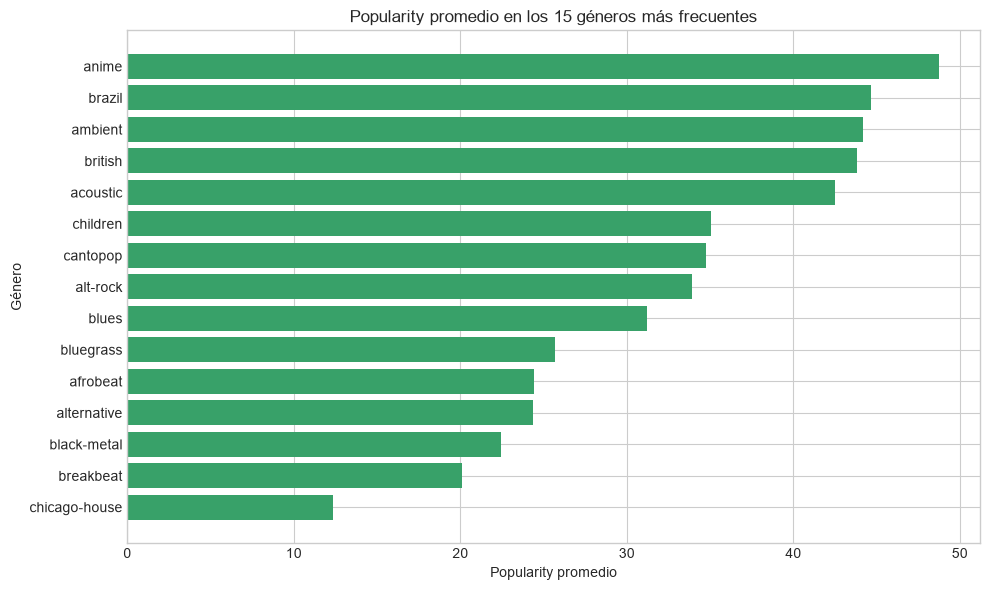

Se muestran los 15 géneros más frecuentes para no saturar la visualización. La media no identifica por sí sola un género como 'más popular': debe interpretarse junto al número de registros y la cobertura del dataset.


In [59]:
genre_summary = df.groupby("track_genre", observed=False)["popularity"].agg(["count", "mean", "median", "std"]).sort_values("count", ascending=False) if "track_genre" in df else pd.DataFrame()
top_genres = genre_summary.head(15).sort_values("mean")
display(top_genres)
plt.figure(figsize=(10, 6))
plt.barh(top_genres.index.astype(str), top_genres["mean"], color="#38a169")
plt.title("Popularity promedio en los 15 géneros más frecuentes")
plt.xlabel("Popularity promedio")
plt.ylabel("Género")
plt.tight_layout(); plt.show()
print("Se muestran los 15 géneros más frecuentes para no saturar la visualización. La media no identifica por sí sola un género como 'más popular': debe interpretarse junto al número de registros y la cobertura del dataset.")

## 18. Análisis de contenido explícito

,count,mean,median,std,porcentaje
explicit,,,,,
False,104253,32.938,34.000,22.084,91.450
True,9747,36.454,37.000,24.318,8.550


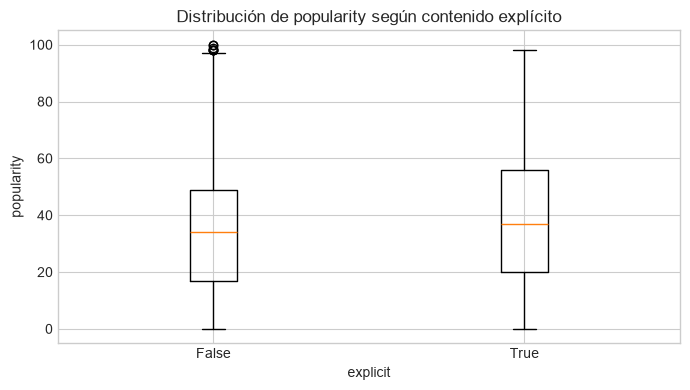

La comparación es descriptiva. No permite afirmar que el contenido explícito cause una mayor o menor popularidad.


In [60]:
explicit_summary = df.groupby("explicit", observed=False)["popularity"].agg(["count", "mean", "median", "std"]) if "explicit" in df else pd.DataFrame()
if not explicit_summary.empty:
    explicit_summary["porcentaje"] = explicit_summary["count"] / len(df) * 100
display(explicit_summary)
if "explicit" in df:
    groups = [group["popularity"].dropna() for _, group in df.groupby("explicit", observed=False)]
    labels = [str(value) for value, _ in df.groupby("explicit", observed=False)]
    plt.figure(figsize=(7, 4))
    plt.boxplot(groups, tick_labels=labels)
    plt.title("Distribución de popularity según contenido explícito")
    plt.xlabel("explicit")
    plt.ylabel("popularity")
    plt.tight_layout(); plt.show()
print("La comparación es descriptiva. No permite afirmar que el contenido explícito cause una mayor o menor popularidad.")

In [61]:
def cramers_v(x, y):
    """Calcula Cramér's V para dos variables categóricas sin imputación."""
    table = pd.crosstab(x, y)
    if table.shape[0] < 2 or table.shape[1] < 2:
        return np.nan
    chi2 = chi2_contingency(table, correction=False)[0]
    n = table.to_numpy().sum()
    return np.sqrt((chi2 / n) / min(table.shape[0] - 1, table.shape[1] - 1))

if {"explicit", "track_genre"}.issubset(df.columns):
    explicit_genre_v = cramers_v(df["explicit"], df["track_genre"])
    print(f"Cramér's V entre explicit y track_genre: {explicit_genre_v:.3f}.")
    print("Esta medida describe asociación entre dos variables categóricas y no se utiliza para inferir causalidad ni para evaluar directamente popularity.")

Cramér's V entre explicit y track_genre: 0.402.
Esta medida describe asociación entre dos variables categóricas y no se utiliza para inferir causalidad ni para evaluar directamente popularity.


## 19. Validación de rangos

In [62]:
expected_ranges = {
    "popularity": (0, 100), "danceability": (0, 1), "energy": (0, 1),
    "speechiness": (0, 1), "acousticness": (0, 1), "instrumentalness": (0, 1),
    "liveness": (0, 1), "valence": (0, 1), "key": (0, 11), "mode": (0, 1),
    "time_signature": (1, 7), "duration_ms": (0, np.inf), "tempo": (0, np.inf),
}
validation_rows = []
for column, (low, high) in expected_ranges.items():
    if column in df:
        invalid = ((df[column] < low) | (df[column] > high)).sum()
        validation_rows.append({
            "Variable": column, "Mínimo": df[column].min(), "Máximo": df[column].max(),
            "Rango esperado": f"[{low}, {high}]", "Valores inválidos": int(invalid),
            "% inválidos": invalid / len(df) * 100,
        })
validations = pd.DataFrame(validation_rows).set_index("Variable")
display(validations)
if validations["Valores inválidos"].sum() == 0:
    print("No se encontraron valores fuera de los rangos definidos.")
else:
    print(f"Se detectaron {int(validations['Valores inválidos'].sum()):,} valores fuera de rango; se reportan sin eliminarlos automáticamente.")

,Mínimo,Máximo,Rango esperado,Valores inválidos,% inválidos
Variable,,,,,
popularity,0.000,100.000,"[0, 100]",0,0.000
danceability,0.000,0.985,"[0, 1]",0,0.000
energy,0.000,1.000,"[0, 1]",0,0.000
speechiness,0.000,0.965,"[0, 1]",0,0.000
acousticness,0.000,0.996,"[0, 1]",0,0.000
instrumentalness,0.000,1.000,"[0, 1]",0,0.000
liveness,0.000,1.000,"[0, 1]",0,0.000
valence,0.000,0.995,"[0, 1]",0,0.000
key,0.000,11.000,"[0, 11]",0,0.000


Se detectaron 163 valores fuera de rango; se reportan sin eliminarlos automáticamente.


## 20. Detección de valores atípicos mediante IQR

,Q1,Q3,IQR,Límite inferior,Límite superior,Outliers,% outliers
Variable,,,,,,,
duration_ms,"174,066.000","261,506.000","87,440.000","42,906.000","392,666.000",5617,4.927
loudness,-10.013,-5.003,5.010,-17.528,2.512,6173,5.415
tempo,99.219,140.071,40.852,37.940,201.349,617,0.541
speechiness,0.036,0.085,0.049,-0.037,0.157,13211,11.589
instrumentalness,0.000,0.049,0.049,-0.074,0.123,25246,22.146
liveness,0.098,0.273,0.175,-0.165,0.536,8642,7.581
popularity,17.000,50.000,33.000,-32.500,99.500,2,0.002


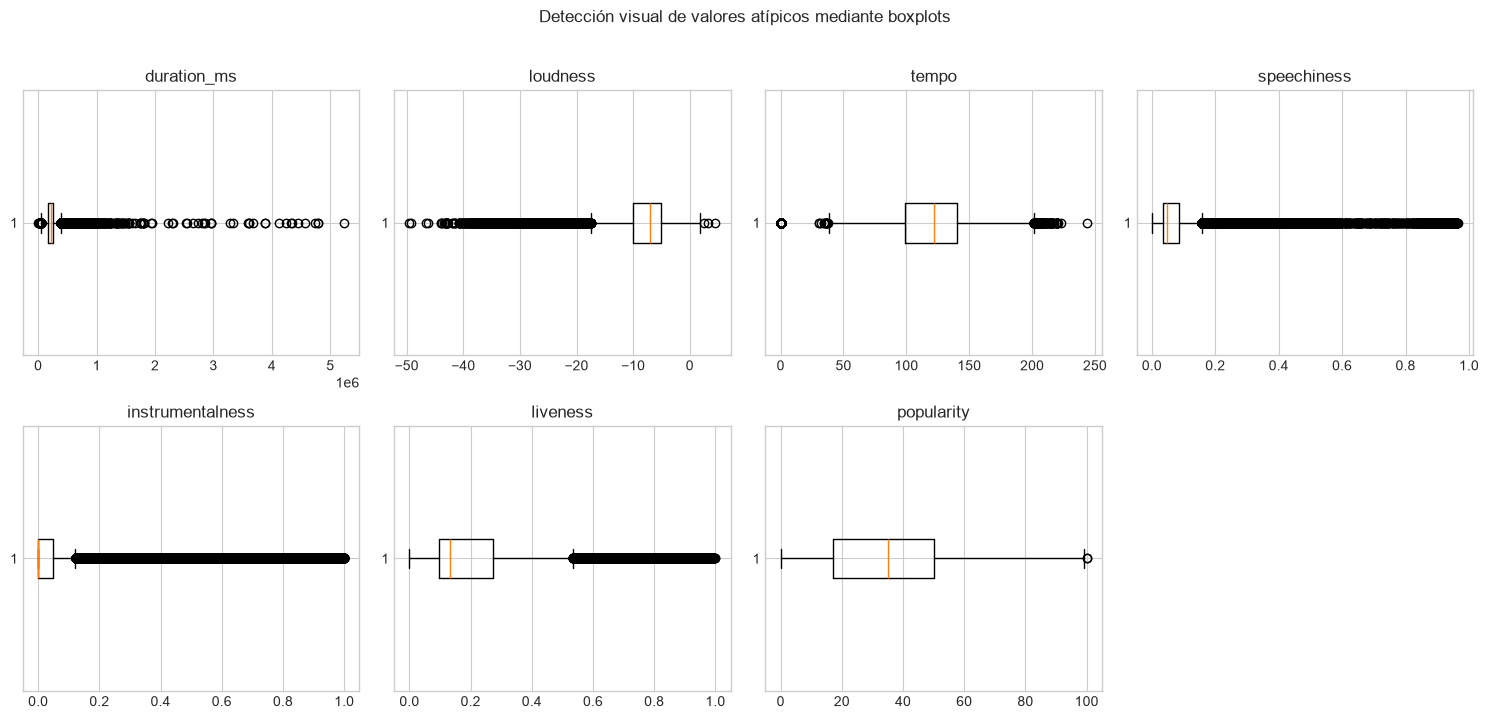

Los valores atípicos no se eliminan automáticamente porque pueden representar canciones reales con características poco frecuentes. Su tratamiento requiere contexto adicional y podría introducir sesgo si se eliminan sin justificación.


In [63]:
outlier_variables = [column for column in ["duration_ms", "loudness", "tempo", "speechiness", "instrumentalness", "liveness", "popularity"] if column in df]
outlier_rows = []
for column in outlier_variables:
    q1, q3 = df[column].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    count = int(((df[column] < lower) | (df[column] > upper)).sum())
    outlier_rows.append({
        "Variable": column, "Q1": q1, "Q3": q3, "IQR": iqr,
        "Límite inferior": lower, "Límite superior": upper,
        "Outliers": count, "% outliers": count / len(df) * 100,
    })
outlier_summary = pd.DataFrame(outlier_rows).set_index("Variable")
display(outlier_summary)

fig, axes = plt.subplots(2, 4, figsize=(15, 7))
for ax, column in zip(axes.flat, outlier_variables):
    ax.boxplot(df[column].dropna(), orientation="horizontal")
    ax.set_title(column)
for ax in axes.flat[len(outlier_variables):]:
    ax.set_visible(False)
fig.suptitle("Detección visual de valores atípicos mediante boxplots", y=1.02)
plt.tight_layout(); plt.show()
print("Los valores atípicos no se eliminan automáticamente porque pueden representar canciones reales con características poco frecuentes. Su tratamiento requiere contexto adicional y podría introducir sesgo si se eliminan sin justificación.")

### 20.1 Principales patrones encontrados

In [64]:
most_positive = pearson.idxmax()
most_negative = pearson.idxmin()
genre_with_highest_mean = genre_summary["mean"].idxmax() if not genre_summary.empty else "no disponible"
total_iqr_detections = int(outlier_summary["Outliers"].sum())

display(Markdown(
    f"- La asociación de Pearson más positiva con `popularity` es **{most_positive}** ({pearson[most_positive]:.3f}); la más negativa es **{most_negative}** ({pearson[most_negative]:.3f}).\n"
    "- Estas asociaciones individuales deben leerse con cautela: no implican causalidad ni descartan relaciones no lineales o combinadas.\n"
    f"- El género con mayor promedio observado de popularity es **{genre_with_highest_mean}**; este resultado depende de la cobertura y distribución del dataset.\n"
    f"- El método IQR registró **{total_iqr_detections:,} detecciones acumuladas de valores atípicos** en las variables evaluadas. Esta suma puede contar una misma canción en más de una variable y no representa necesariamente esa cantidad de canciones únicas."
))

- La asociación de Pearson más positiva con `popularity` es **loudness** (0.050); la más negativa es **instrumentalness** (-0.095).
- Estas asociaciones individuales deben leerse con cautela: no implican causalidad ni descartan relaciones no lineales o combinadas.
- El género con mayor promedio observado de popularity es **pop-film**; este resultado depende de la cobertura y distribución del dataset.
- El método IQR registró **59,508 detecciones acumuladas de valores atípicos** en las variables evaluadas. Esta suma puede contar una misma canción en más de una variable y no representa necesariamente esa cantidad de canciones únicas.

## 21. Preparación de datos

In [65]:
df_clean = df.copy()
before_profile = {
    "filas": len(df), "columnas": df.shape[1], "faltantes": int(df.isna().sum().sum()),
    "duplicados_exactos": int(df.duplicated().sum()), "tipos": df.dtypes.astype(str).to_dict(),
}

removed_columns = []
is_artificial_index = False
if "Unnamed: 0" in df_clean.columns:
    is_artificial_index = np.array_equal(df_clean["Unnamed: 0"].to_numpy(), np.arange(len(df_clean)))
    if is_artificial_index:
        df_clean = df_clean.drop(columns="Unnamed: 0")
        removed_columns.append("Unnamed: 0")

text_metadata = [column for column in ["artists", "album_name", "track_name"] if column in df_clean]
for column in text_metadata:
    df_clean[column] = df_clean[column].fillna("Desconocido")
if "explicit" in df_clean:
    df_clean["explicit"] = df_clean["explicit"].astype("boolean")
if "track_genre" in df_clean:
    df_clean["track_genre"] = df_clean["track_genre"].astype("category")

print(f"Unnamed: 0 coincide exactamente con un índice artificial: {is_artificial_index}.")
print(f"Columnas eliminadas: {removed_columns if removed_columns else 'ninguna'}.")
print("Los faltantes de artists, album_name y track_name se etiquetan como 'Desconocido'. No se eliminan automáticamente outliers, track_id repetidos, canciones ni variables potencialmente útiles.")

Unnamed: 0 coincide exactamente con un índice artificial: True.
Columnas eliminadas: ['Unnamed: 0'].
Los faltantes de artists, album_name y track_name se etiquetan como 'Desconocido'. No se eliminan automáticamente outliers, track_id repetidos, canciones ni variables potencialmente útiles.


## 22. Dataset preparado y comparación antes después

In [66]:
prepared_profile = pd.DataFrame({
    "tipo": df_clean.dtypes.astype(str),
    "faltantes": df_clean.isna().sum(),
    "valores_unicos": df_clean.nunique(dropna=True),
})

display(prepared_profile)

after_profile = {
    "filas": len(df_clean),
    "columnas": df_clean.shape[1],
    "faltantes": int(df_clean.isna().sum().sum()),
    "duplicados_exactos": int(df_clean.duplicated().sum()),
    "tipos": df_clean.dtypes.astype(str).to_dict(),
}

modified_types = []

for column in df_clean.columns:
    before_type = before_profile["tipos"].get(column)
    after_type = after_profile["tipos"].get(column)

    if before_type != after_type:
        modified_types.append(
            f"{column}: {before_type} -> {after_type}"
        )

comparison = pd.DataFrame([
    ["Filas", before_profile["filas"], after_profile["filas"]],
    ["Columnas", before_profile["columnas"], after_profile["columnas"]],
    ["Faltantes", before_profile["faltantes"], after_profile["faltantes"]],
    ["Duplicados exactos", before_profile["duplicados_exactos"], after_profile["duplicados_exactos"]],
    [
        "Columnas eliminadas",
        "Ninguna",
        ", ".join(removed_columns) if removed_columns else "Ninguna"
    ],
    [
        "Tipos modificados",
        "Tipos originales",
        ", ".join(modified_types) if modified_types else "Ninguno"
    ],
], columns=["Indicador", "Antes", "Después"])

display(comparison)

print(
    "La comparación documenta dinámicamente los cambios realizados durante "
    "la preparación. No se eliminan automáticamente outliers, registros con "
    "track_id repetido ni variables potencialmente útiles."
)

,tipo,faltantes,valores_unicos
track_id,str,0,89741
artists,str,0,31438
album_name,str,0,46590
track_name,str,0,73609
popularity,int64,0,101
duration_ms,int64,0,50697
explicit,boolean,0,2
danceability,float64,0,1174
energy,float64,0,2083
key,int64,0,12


,Indicador,Antes,Después
0,Filas,114000,114000
1,Columnas,21,20
2,Faltantes,3,0
3,Duplicados exactos,0,450
4,Columnas eliminadas,Ninguna,Unnamed: 0
5,Tipos modificados,Tipos originales,"explicit: bool -> boolean, track_genre: str ->..."


La comparación documenta dinámicamente los cambios realizados durante la preparación. No se eliminan automáticamente outliers, registros con track_id repetido ni variables potencialmente útiles.


## 23. Selección preliminar de variables

`popularity` es el target. `track_id` se excluye por ser un identificador. `artists`, `album_name` y `track_name` se reservan como metadatos de alta cardinalidad con riesgo de sobreajuste si se usan sin una estrategia de codificación validada. No se descartan variables musicales por tener correlación lineal baja: podrían aportar información no lineal o combinada.

In [67]:
target = "popularity"
identifier_columns = [column for column in ["track_id"] if column in df_clean]
descriptive_columns = [column for column in ["artists", "album_name", "track_name"] if column in df_clean]
candidate_features = [column for column in numeric_features + ["explicit", "track_genre"] if column in df_clean]
X_future = df_clean[candidate_features].copy()
y_future = df_clean[target].copy()
print(f"Target: {target}")
print(f"Identificadores excluidos: {identifier_columns}")
print(f"Metadatos reservados: {descriptive_columns}")
print(f"Variables candidatas: {candidate_features}")
print(f"X futuro: {X_future.shape}; y futuro: {y_future.shape}. No se entrena un modelo en esta evaluación.")

Target: popularity
Identificadores excluidos: ['track_id']
Metadatos reservados: ['artists', 'album_name', 'track_name']
Variables candidatas: ['duration_ms', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'explicit', 'track_genre']
X futuro: (114000, 15); y futuro: (114000,). No se entrena un modelo en esta evaluación.


## 24. Prevención de data leakage

Para la etapa futura, primero se separarán train y test. Luego se ajustarán imputadores, escaladores y codificadores solo sobre train; test se transformará exclusivamente con los objetos ya ajustados. No se aplicará `fit_transform` a todo el dataset antes del split. Esta secuencia evita que información del conjunto de prueba influya en el entrenamiento.

## 25. Metodología CRISP DM

| Etapa | Estado | Evidencia |
|---|---|---|
| Business Understanding | COMPLETADO | Problema, objetivo y KPIs definidos. |
| Data Understanding | COMPLETADO | Inspección, calidad, EDA y asociaciones. |
| Data Preparation | COMPLETADO | `df_clean`, tratamiento justificado y comparación antes/después. |
| Modeling | PENDIENTE | Fuera del alcance actual. |
| Evaluation | PENDIENTE | Requerirá MAE, RMSE y R² en test. |
| Deployment | FUERA DEL ALCANCE | No corresponde a esta evaluación. |

## 26. Sesgos, ética, privacidad y limitaciones

**Sesgos potenciales.** La distribución de canciones entre géneros puede ser desigual. `popularity` podría reflejar exposición previa, promoción, contexto temporal o comportamiento de usuarios, no solo rasgos musicales. Variables no observadas y sesgos históricos podrían afectar un modelo posterior; esta evidencia no permite afirmar discriminación.

**Ética.** Popularidad no equivale a calidad artística. Un modelo no debe excluir automáticamente artistas, canciones o géneros; requiere revisión humana, análisis de desempeño por género y comunicación de sus límites. Las asociaciones observadas no son conclusiones causales.

**Privacidad.** El dataset contiene metadatos de canciones y artistas, identificadores de pistas y atributos musicales; no se observan datos personales directos de usuarios. Se recomienda minimización de datos, acceso controlado, uso académico y no vincular registros con perfiles personales. El material disponible no documenta el procedimiento original de captura del dataset.

**Limitaciones.** No se conoce la captura original ni se incluyen factores relevantes como promoción, audiencia o fecha. Además, este notebook no realiza validación temporal ni entrenamiento de modelos.

## 27. Conclusiones del EDA y próxima etapa

In [68]:
missing_total = int(df.isna().sum().sum())
total_iqr_detections = int(outlier_summary["Outliers"].sum())
display(Markdown(
    f"El dataset contiene **{df.shape[0]:,} registros** y **{df.shape[1]:,} variables** antes de la preparación. Se identificaron **{missing_total:,} valores faltantes**, **{exact_duplicates:,} duplicados exactos**, **{additional_track_id_repetitions:,} repeticiones adicionales de `track_id`** y **{records_with_repeated_ids:,} registros asociados a IDs repetidos**; todas estas métricas se calculan directamente desde los datos.\n\n"
    f"El EDA muestra que `popularity` varía entre {df_clean['popularity'].min():.0f} y {df_clean['popularity'].max():.0f}; las asociaciones individuales más destacadas son {most_positive} ({pearson[most_positive]:.3f}) y {most_negative} ({pearson[most_negative]:.3f}). El IQR produjo {total_iqr_detections:,} detecciones acumuladas en las variables evaluadas. Estos resultados justifican un enfoque multivariable, pero no permiten establecer causalidad.\n\n"
    "La próxima etapa debe separar entrenamiento y prueba antes de ajustar transformadores, construir un pipeline de preprocesamiento y comparar modelos de regresión con MAE, RMSE y R². También debe evaluar el desempeño por género y documentar el uso responsable."
))

El dataset contiene **114,000 registros** y **21 variables** antes de la preparación. Se identificaron **3 valores faltantes**, **0 duplicados exactos**, **24,259 repeticiones adicionales de `track_id`** y **40,900 registros asociados a IDs repetidos**; todas estas métricas se calculan directamente desde los datos.

El EDA muestra que `popularity` varía entre 0 y 100; las asociaciones individuales más destacadas son loudness (0.050) y instrumentalness (-0.095). El IQR produjo 59,508 detecciones acumuladas en las variables evaluadas. Estos resultados justifican un enfoque multivariable, pero no permiten establecer causalidad.

La próxima etapa debe separar entrenamiento y prueba antes de ajustar transformadores, construir un pipeline de preprocesamiento y comparar modelos de regresión con MAE, RMSE y R². También debe evaluar el desempeño por género y documentar el uso responsable.